# 00 — Problem Setup

A missile intercept problem sounds complicated. It is not — at its core it is just a geometry question with time in it.

**The setup:**
- You are at a fixed launch site
- A target is somewhere else and moving
- Your interceptor travels at a known speed
- You need to fire in a direction such that the interceptor and target arrive at the same place at the same time

The hard part is not the math. The hard part is realizing that you cannot aim *at the target* — by the time your interceptor arrives, the target will have moved. You have to aim *at where the target will be*.

This notebook defines the problem precisely, names every variable you will need, and builds the initial map visualization before any simulation begins.

In [1]:
import math

# ── Geometry helpers (carried forward from Module 07) ───────────────────────

def compute_bearing(p1, p2):
    """Initial bearing from p1 to p2. Inputs: [lon, lat]. Output: [0, 360)."""
    lon1, lat1 = math.radians(p1[0]), math.radians(p1[1])
    lon2, lat2 = math.radians(p2[0]), math.radians(p2[1])
    d_lon = lon2 - lon1
    x = math.sin(d_lon) * math.cos(lat2)
    y = math.cos(lat1) * math.sin(lat2) - math.sin(lat1) * math.cos(lat2) * math.cos(d_lon)
    return (math.degrees(math.atan2(x, y)) + 360) % 360

def haversine_km(p1, p2):
    """Great-circle distance in km. Inputs: [lon, lat]."""
    R = 6371.0
    lon1, lat1 = math.radians(p1[0]), math.radians(p1[1])
    lon2, lat2 = math.radians(p2[0]), math.radians(p2[1])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

def destination_point(origin, bearing_deg, distance_km):
    """Point reached by travelling distance_km from origin at bearing_deg."""
    R = 6371.0
    d   = distance_km / R
    brg = math.radians(bearing_deg)
    lat1 = math.radians(origin[1])
    lon1 = math.radians(origin[0])
    lat2 = math.asin(math.sin(lat1)*math.cos(d) + math.cos(lat1)*math.sin(d)*math.cos(brg))
    lon2 = lon1 + math.atan2(math.sin(brg)*math.sin(d)*math.cos(lat1),
                              math.cos(d) - math.sin(lat1)*math.sin(lat2))
    return [math.degrees(lon2), math.degrees(lat2)]

print("Helpers loaded.")

Helpers loaded.


## 1. What Is an Intercept Problem?

An intercept problem asks: **where and when can a moving pursuer meet a moving target?**

The three classic variants are:

| Problem | Target | Pursuer | Question |
|---------|--------|---------|---------|
| **Pure pursuit** | Moving | Always aims directly at target | Does pursuer ever catch target? |
| **Constant-bearing intercept** | Moving at known velocity | Fires once in fixed direction | Which direction guarantees meeting? |
| **Proportional navigation** | Maneuvering | Adjusts heading continuously | Advanced — out of scope here |

This module covers the first two. Pure pursuit is intuitive but often inefficient. Constant-bearing intercept is what real guidance systems use for predictable targets.

The geometry connecting them is the same — distance, bearing, and time — just applied differently.

## 2. The Ingredients

Every intercept problem uses the same five variables. Name them explicitly before writing any code — ambiguity here causes bugs that are hard to trace.

```text
shooter_pos      [lon, lat]     — fixed launch site
target_pos       [lon, lat]     — target's current position
target_speed     km/h           — target's constant speed
target_heading   degrees        — target's constant compass bearing
shooter_speed    km/h           — interceptor's constant speed
```

From these, two derived quantities appear in every calculation:

```text
current_distance   = haversine_km(shooter_pos, target_pos)
current_bearing    = compute_bearing(shooter_pos, target_pos)
```

The goal is to find `intercept_point` — the future position where the paths cross — and `fire_bearing` — the direction to aim.

These are what previous modules have been building toward:
- **Module 06** gave you `haversine_km`
- **Module 07** gave you `compute_bearing` and `destination_point`
- **This module** puts them together with time

In [2]:
# Define the scenario used throughout this module
shooter_pos    = [-98.49, 33.91]   # Wichita Falls — fixed launch site
target_pos     = [-101.0, 36.5]    # northwest — incoming
target_speed   = 300               # km/h
target_heading = 135               # heading southeast — toward shooter
shooter_speed  = 600               # km/h — 2× target speed

# Derived quantities at t=0
current_distance = haversine_km(shooter_pos, target_pos)
current_bearing  = compute_bearing(shooter_pos, target_pos)

print("=== Scenario: t = 0 ===")
print(f"  Shooter:         {shooter_pos}  (Wichita Falls)")
print(f"  Target:          {target_pos}")
print(f"  Target heading:  {target_heading}°  (southeast)")
print(f"  Target speed:    {target_speed} km/h")
print(f"  Shooter speed:   {shooter_speed} km/h")
print()
print(f"  Current distance: {current_distance:.1f} km")
print(f"  Bearing to target: {current_bearing:.1f}°")
print()
# Naive flight time if target were stationary
naive_time = current_distance / shooter_speed
print(f"  Naive time-to-target (stationary): {naive_time:.2f} h  ({naive_time*60:.0f} min)")
print(f"  Target travels in that time:       {target_speed * naive_time:.1f} km")
print()
print("  → Aiming at the current target position is wrong by that much.")

=== Scenario: t = 0 ===
  Shooter:         [-98.49, 33.91]  (Wichita Falls)
  Target:          [-101.0, 36.5]
  Target heading:  135°  (southeast)
  Target speed:    300 km/h
  Shooter speed:   600 km/h

  Current distance: 367.3 km
  Bearing to target: 322.3°

  Naive time-to-target (stationary): 0.61 h  (37 min)
  Target travels in that time:       183.7 km

  → Aiming at the current target position is wrong by that much.


## 3. Why Aiming at the Current Position Fails

The naive approach: compute the bearing to the target right now, fire in that direction. 

The problem: while your interceptor is travelling, the target is also moving. By the time your interceptor reaches the target's *current* position, the target is somewhere else entirely.

The size of the error grows with distance and shrinks with speed ratio. For our scenario:
- target moves ~150 km while the interceptor is in flight
- that is a miss distance of 150 km from the intended point

The two paths never cross — the interceptor chases a ghost.

In [3]:
# Show the failure clearly: naive aim point vs. where the target actually is
naive_bearing   = compute_bearing(shooter_pos, target_pos)
naive_aim_point = destination_point(shooter_pos, naive_bearing, current_distance)
# How far does the interceptor travel before reaching the aim point?
time_of_flight  = current_distance / shooter_speed
# Where is the target at that moment?
target_at_tof   = destination_point(target_pos, target_heading, target_speed * time_of_flight)

miss_distance = haversine_km(naive_aim_point, target_at_tof)

print("Naive fire solution:")
print(f"  Fire bearing:       {naive_bearing:.1f}°")
print(f"  Time of flight:     {time_of_flight:.3f} h  ({time_of_flight*60:.1f} min)")
print(f"  Interceptor lands:  {[round(c,3) for c in naive_aim_point]}")
print(f"  Target is at:       {[round(c,3) for c in target_at_tof]}")
print(f"  Miss distance:      {miss_distance:.1f} km")

Naive fire solution:
  Fire bearing:       322.3°
  Time of flight:     0.612 h  (36.7 min)
  Interceptor lands:  [-101.0, 36.5]
  Target is at:       [-99.569, 35.323]
  Miss distance:      183.7 km


## 4. Visualizing the Initial Setup

A map puts every variable in context. Three things to show:
1. The shooter (launch site)
2. The target's current position
3. The target's projected path — where it will be over the next several steps
4. The naive aim point — where the interceptor would land if fired now

Seeing the target path and the naive aim point side by side makes the problem concrete.

In [4]:
from ipyleaflet import Map, GeoJSON, basemaps

m = Map(center=(33.87, -98.52), zoom=10, basemap=basemaps.CartoDB.Positron)


# Project target path over 2 hours in 15-min steps
dt = 0.25  # hours per step
n_steps = 8
target_path = [target_pos]
for i in range(1, n_steps + 1):
    target_path.append(
        destination_point(target_pos, target_heading, target_speed * dt * i)
    )

featureColl = {"type": "FeatureCollection", "features": []}

# Build GeoJSON layers
shooter_fc = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": shooter_pos},
            "properties": {"label": "Shooter (Wichita Falls)"},
        }
    ],
}

featureColl["features"].extend(shooter_fc["features"])

target_start_fc = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": target_pos},
            "properties": {"label": "Target (t=0)"},
        }
    ],
}

featureColl["features"].extend(target_start_fc["features"])

target_path_fc = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "geometry": {"type": "LineString", "coordinates": target_path},
            "properties": {"label": "Target projected path"},
        }
    ],
}

featureColl["features"].extend(target_path_fc["features"])

naive_aim_fc = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": naive_aim_point},
            "properties": {"label": "Naive aim point (WRONG)"},
        },
        {
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": target_at_tof},
            "properties": {"label": "Target actual position at TOF"},
        },
    ],
}

featureColl["features"].extend(naive_aim_fc["features"])


naive_line_fc = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "geometry": {
                "type": "LineString",
                "coordinates": [shooter_pos, naive_aim_point],
            },
            "properties": {},
        }
    ],
}

featureColl["features"].extend(naive_line_fc["features"])

print(featureColl)

m = Map(center=(35.5, -99.5), zoom=6, basemap=basemaps.CartoDB.Positron)


m.add(
    GeoJSON(
        data=target_path_fc, style={"color": "#457b9d", "weight": 2, "dashArray": "5"}
    )
)
m.add(
    GeoJSON(
        data=naive_line_fc, style={"color": "#e63946", "weight": 1.5, "dashArray": "4"}
    )
)
m.add(
    GeoJSON(
        data=shooter_fc,
        point_style={"radius": 7, "color": "#e63946", "fillOpacity": 1.0},
    )
)
m.add(
    GeoJSON(
        data=target_start_fc,
        point_style={"radius": 7, "color": "#457b9d", "fillOpacity": 1.0},
    )
)
m.add(
    GeoJSON(
        data=naive_aim_fc,
        point_style={"radius": 6, "color": "#f4a261", "fillOpacity": 1.0},
    )
)
m

{'type': 'FeatureCollection', 'features': [{'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [-98.49, 33.91]}, 'properties': {'label': 'Shooter (Wichita Falls)'}}, {'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [-101.0, 36.5]}, 'properties': {'label': 'Target (t=0)'}}, {'type': 'Feature', 'geometry': {'type': 'LineString', 'coordinates': [[-101.0, 36.5], [-100.41031466059998, 36.02160829554341], [-99.8277673020356, 35.54036481359576], [-99.25218882487266, 35.056353324309036], [-98.68341234057166, 34.569655297618866], [-98.12127324403734, 34.080349966816954], [-97.565609273434, 33.58851439169484], [-97.01626055830972, 33.094223521118415], [-96.47306965700908, 32.59755025491092]]}, 'properties': {'label': 'Target projected path'}}, {'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [-101.0, 36.50000000000001]}, 'properties': {'label': 'Naive aim point (WRONG)'}}, {'type': 'Feature', 'geometry': {'type': 'Point', 'coordinates': [-99.568599705

Map(center=[35.5, -99.5], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_ou…

**Red dot** — shooter. **Blue dot** — target at t=0. **Dashed blue** — where the target will be over the next 2 hours. **Dashed red line** — the naive fire solution. **Orange dots** — where the interceptor lands (naive aim point) vs. where the target actually is at that moment.

The orange dots are not in the same place. That gap is the miss distance.

## 5. The Correct Question

Aiming at the current target position asks: *"where is the target now?"*

The correct question is: *"where will the target be at time `t`, such that my interceptor — travelling distance `shooter_speed × t` — can also reach that point at time `t`?"*

This requires finding a `t` that satisfies:

```text
haversine_km(shooter_pos, target_at_t) = shooter_speed × t
```

where `target_at_t = destination_point(target_pos, target_heading, target_speed × t)`.

This is the equation that the next two notebooks solve — one analytically, one iteratively.

---

## Exercise A — Change the Scenario

Modify the scenario variables below and observe how the miss distance changes.

1. Double the target speed to `600 km/h`. What happens to the miss distance?
2. Halve the shooter speed to `300 km/h`. What happens?
3. Set `target_heading = 315` (target heading away northwest). Does that make the problem easier or harder?

For each case, print the miss distance and write a one-sentence explanation of why it changed.

In [5]:
def naive_miss_distance(shooter_pos, target_pos, target_heading, target_speed, shooter_speed):
    """Compute miss distance when firing naively at the current target position."""
    dist        = haversine_km(shooter_pos, target_pos)
    bearing     = compute_bearing(shooter_pos, target_pos)
    aim_point   = destination_point(shooter_pos, bearing, dist)
    tof         = dist / shooter_speed
    target_tof  = destination_point(target_pos, target_heading, target_speed * tof)
    return haversine_km(aim_point, target_tof)


scenarios = [
    ("Baseline",              target_pos, 135, 300, 600),
    ("2× target speed",       target_pos, 135, 600, 600),
    ("½ shooter speed",       target_pos, 135, 300, 300),
    ("Target heading away",   target_pos, 315, 300, 600),
]

print(f"{'Scenario':<24} {'Miss distance':>14}")
print("-" * 42)

for label, tpos, thead, tspeed, sspeed in scenarios:
    miss = naive_miss_distance(shooter_pos, tpos, thead, tspeed, sspeed)
    print(f"{label:<24} {miss:>12.1f} km")


# Explanations:

# Baseline:
# The target moves while the shooter is traveling, so aiming at the current
# position causes the interceptor to miss by a moderate distance.

# 2× target speed:
# The miss distance becomes much larger because the target travels farther
# during the projectile's time of flight.

# ½ shooter speed:
# The miss distance also increases because the shooter takes longer to arrive,
# giving the target more time to move away from the aim point.

# Target heading away:
# This makes the problem harder because the target is moving away from the
# shooter instead of toward it, increasing separation over time.

Scenario                  Miss distance
------------------------------------------
Baseline                        183.7 km
2× target speed                 367.3 km
½ shooter speed                 367.3 km
Target heading away             183.7 km


## Exercise B — Map the Correct Question

For each time step `t` from 0.1 to 1.5 hours (in steps of 0.1), compute:
- Where the target will be at time `t`
- The distance from the shooter to that future position
- The distance the interceptor can travel in time `t` (`shooter_speed × t`)

Plot both distances on a single matplotlib chart against time. The intercept time is where the two lines cross.

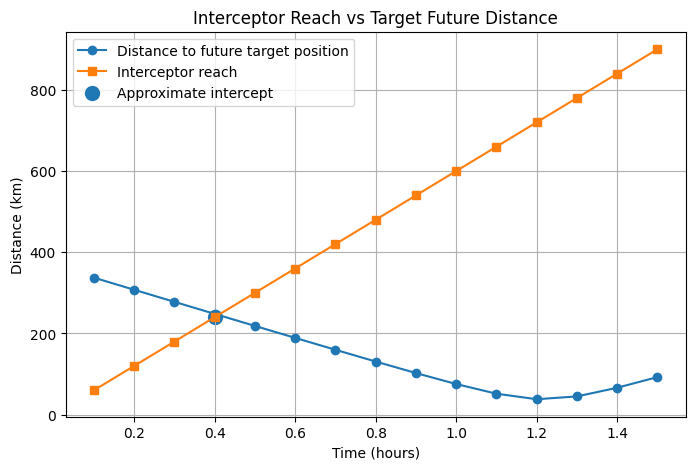

Approximate intercept time: 0.4 hours
Approximate intercept distance: 240.0 km


In [6]:
import matplotlib.pyplot as plt

times = [t / 10 for t in range(1, 16)]  # 0.1 to 1.5 hours

target_distances = []
interceptor_distances = []

# Compute distances for each time step
for t in times:
    
    # Where the target will be after time t
    target_future = destination_point(
        target_pos,
        target_heading,
        target_speed * t
    )
    
    # Distance from shooter to target future position
    dist_to_future = haversine_km(shooter_pos, target_future)
    
    # Distance interceptor can travel in time t
    interceptor_reach = shooter_speed * t
    
    target_distances.append(dist_to_future)
    interceptor_distances.append(interceptor_reach)

# Find approximate crossing point
best_index = 0
smallest_diff = float("inf")

for i in range(len(times)):
    diff = abs(target_distances[i] - interceptor_distances[i])
    
    if diff < smallest_diff:
        smallest_diff = diff
        best_index = i

intercept_time = times[best_index]
intercept_distance = interceptor_distances[best_index]

# Plot the two curves
plt.figure(figsize=(8, 5))

plt.plot(times, target_distances,
         marker='o',
         label='Distance to future target position')

plt.plot(times, interceptor_distances,
         marker='s',
         label='Interceptor reach')

# Mark approximate intercept
plt.scatter(intercept_time,
            intercept_distance,
            s=100,
            label='Approximate intercept')

plt.xlabel("Time (hours)")
plt.ylabel("Distance (km)")
plt.title("Interceptor Reach vs Target Future Distance")
plt.grid(True)
plt.legend()

plt.show()

print(f"Approximate intercept time: {intercept_time:.1f} hours")
print(f"Approximate intercept distance: {intercept_distance:.1f} km")

---

## Check Your Understanding

A student sets up the problem with these values:

```python
shooter_speed = 400   # km/h
target_speed  = 200   # km/h
```

They argue: *"The shooter is twice as fast, so it will always catch the target no matter what."*

**Question:** Is this argument correct? Describe a specific geometric scenario — using target heading as the key variable — where a slower interceptor can still fail to intercept even a much slower target.

```python
# your answer here
```


---

No, that argument is not always correct.

Being faster helps, but interception also depends on the geometry of the problem — especially the target heading.

For example, if the target heading is `315°` (northwest), the target is moving away from the shooter instead of toward it. In that case, the interceptor must chase a moving future position that keeps increasing its separation from the shooter.

Even though the shooter is twice as fast (`400 km/h` vs `200 km/h`), the interceptor can still fail to intercept within a given time window if the target continues moving away and the two distance curves never cross.

So interception is not determined only by speed. It also depends on:
- target heading
- initial positions
- distance between objects
- whether the interceptor can reach the target’s future position at the same time

## Next

In [01 — Constant Velocity Intercept](./01-Constant_Velocity_Intercept.ipynb), we solve the intercept problem analytically — computing the fire bearing and time of flight given a target moving at constant speed and heading.